In [5]:
from google.colab import files

uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [6]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
# ===========================================
# Predictive Maintenance using Machine Learning
# Batch 1: Loading and Understanding Data
# ===========================================

# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Set visualization style
sns.set_style("whitegrid")


# Load dataset
df = pd.read_csv("ai4i2020.csv")


# Display first 5 rows
print("First 5 rows:")
display(df.head())


# Dataset shape
print("\nDataset Shape:")
print(df.shape)


# Column names
print("\nColumns:")
print(df.columns.tolist())


# Dataset information
print("\nDataset Information:")
df.info()


# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Dataset Shape:
(10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
# ===========================================
# Batch 2: Data Cleaning & Preprocessing
# ===========================================


# Check missing values
print("Missing Values:")
print(df.isnull().sum())


# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# Remove duplicate rows
df.drop_duplicates(inplace=True)


# Check dataset after removing duplicates
print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


# Check unique values in Type column
print("\nMachine Types:")
print(df["Type"].unique())


# Encode categorical column (Type)
encoder = LabelEncoder()

df["Type"] = encoder.fit_transform(df["Type"])


# Display updated dataset
print("\nDataset After Encoding:")
display(df.head())


# Check data types
print("\nData Types:")
print(df.dtypes)


# Drop unnecessary columns
# UDI and Product ID are identifiers, not useful for prediction
df.drop(
    ["UDI", "Product ID"],
    axis=1,
    inplace=True
)


# Display final dataset columns
print("\nFinal Columns:")
print(df.columns.tolist())


# Separate features and target

X = df.drop(
    "Machine failure",
    axis=1
)

y = df["Machine failure"]


print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate Rows:
0

Dataset Shape After Removing Duplicates:
(10000, 14)

Machine Types:
['M' 'L' 'H']

Dataset After Encoding:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Data Types:
UDI                          int64
Product ID                  object
Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Final Columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Feature Shape:
(10000, 11)

Target Shape:
(10000,)


/tmp/ipykernel_1719/3243434757.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


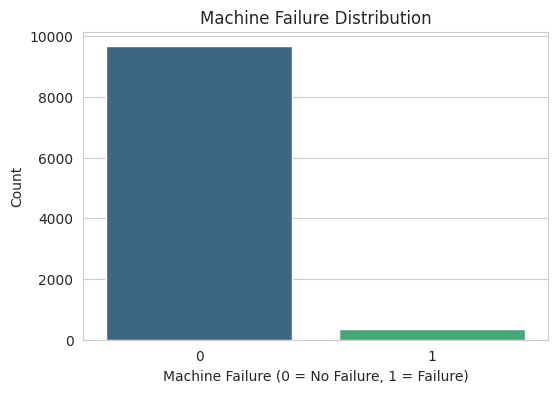

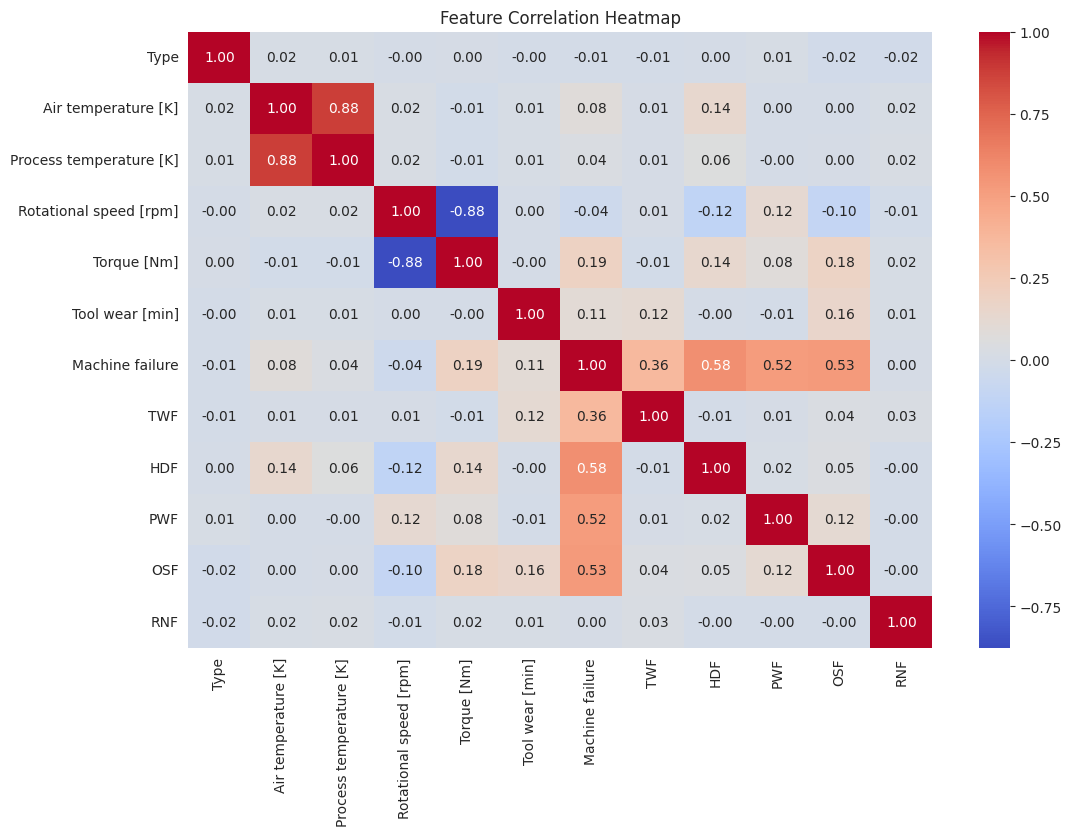

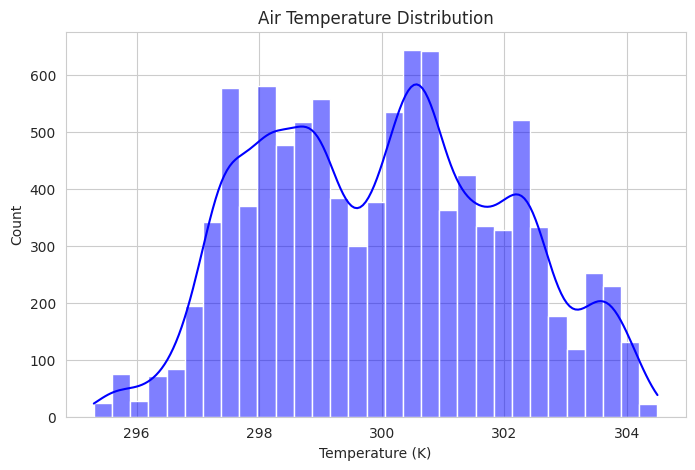

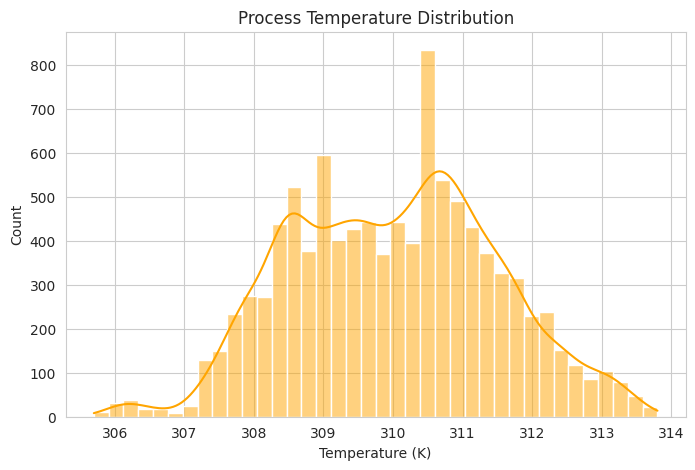

/tmp/ipykernel_1719/3243434757.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


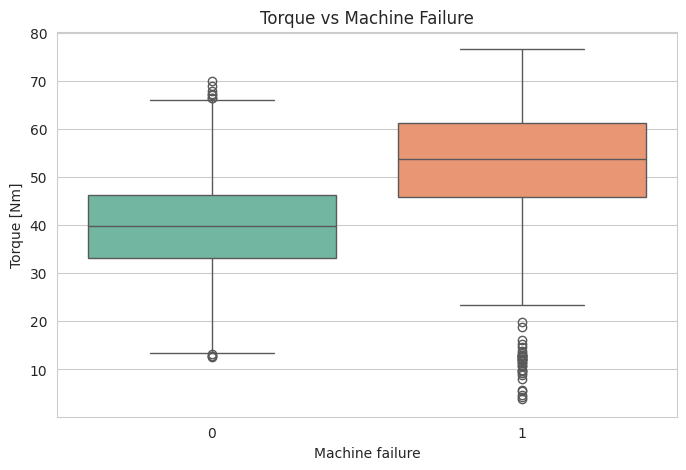

/tmp/ipykernel_1719/3243434757.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


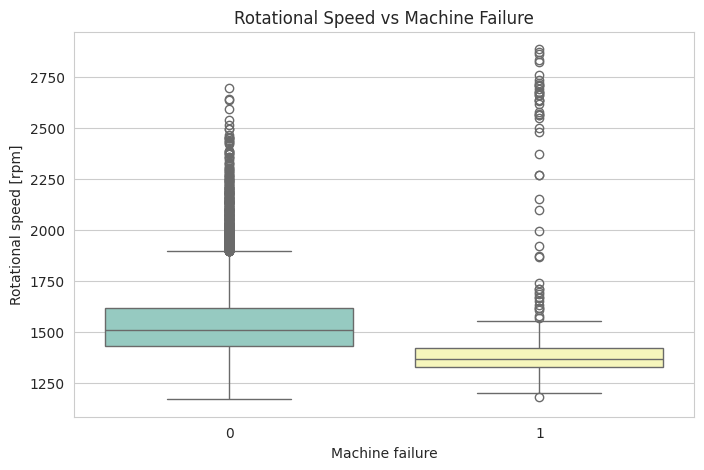

/tmp/ipykernel_1719/3243434757.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


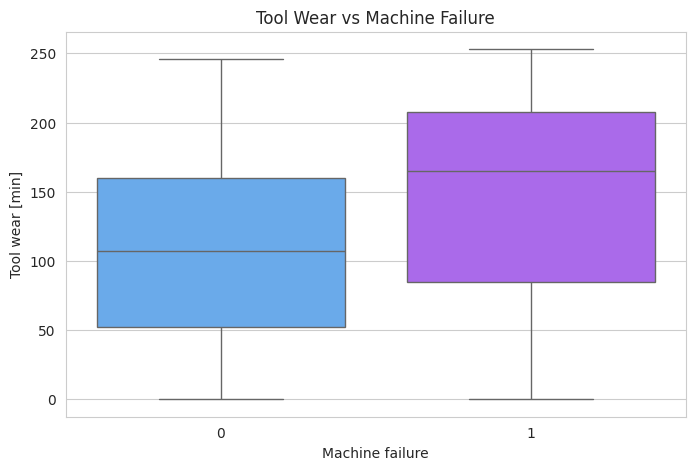

In [9]:
# ===========================================
# Batch 3: Exploratory Data Analysis (EDA)
# ===========================================


# 1. Machine Failure Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x=y,
    palette="viridis"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Count")

plt.show()



# 2. Correlation Heatmap

plt.figure(figsize=(12,8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()



# 3. Air Temperature Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Air temperature [K]"],
    kde=True,
    color="blue"
)

plt.title("Air Temperature Distribution")

plt.xlabel("Temperature (K)")

plt.show()



# 4. Process Temperature Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Process temperature [K]"],
    kde=True,
    color="orange"
)

plt.title("Process Temperature Distribution")

plt.xlabel("Temperature (K)")

plt.show()



# 5. Torque vs Machine Failure

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="Torque [Nm]",
    data=df,
    palette="Set2"
)

plt.title("Torque vs Machine Failure")

plt.show()



# 6. Rotational Speed vs Failure

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="Rotational speed [rpm]",
    data=df,
    palette="Set3"
)

plt.title("Rotational Speed vs Machine Failure")

plt.show()



# 7. Tool Wear Analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="Tool wear [min]",
    data=df,
    palette="cool"
)

plt.title("Tool Wear vs Machine Failure")

plt.show()

In [10]:
# ===========================================
# Batch 4: Machine Learning Model Training
# ===========================================


# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)



# ===========================================
# Model 1: Logistic Regression
# ===========================================

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)


log_prediction = log_model.predict(
    X_test
)


log_accuracy = accuracy_score(
    y_test,
    log_prediction
)


print("\nLogistic Regression Accuracy:")
print(log_accuracy)



# ===========================================
# Model 2: Decision Tree
# ===========================================

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)


tree_prediction = tree_model.predict(
    X_test
)


tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)


print("\nDecision Tree Accuracy:")
print(tree_accuracy)



# ===========================================
# Model 3: Random Forest
# ===========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_prediction = rf_model.predict(
    X_test
)


rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)


print("\nRandom Forest Accuracy:")
print(rf_accuracy)



# Compare Model Performance

model_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest"
        ],

        "Accuracy": [
            log_accuracy,
            tree_accuracy,
            rf_accuracy
        ]
    }
)


print("\nModel Comparison:")

display(model_results)

Training Data Shape:
(8000, 11)

Testing Data Shape:
(2000, 11)

Logistic Regression Accuracy:
0.999

Decision Tree Accuracy:
0.9985

Random Forest Accuracy:
0.999

Model Comparison:


,Model,Accuracy
0,Logistic Regression,0.9990
1,Decision Tree,0.9985
2,Random Forest,0.9990


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Final Model Accuracy:
0.999


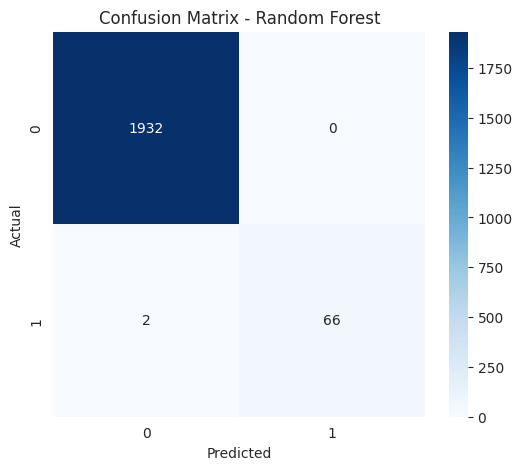

Feature Importance:


,Feature,Importance
7,HDF,0.272093
9,OSF,0.232373
8,PWF,0.200104
6,TWF,0.108812
4,Torque [Nm],0.076630
3,Rotational speed [rpm],0.044600
5,Tool wear [min],0.028837
1,Air temperature [K],0.017290
2,Process temperature [K],0.015728
0,Type,0.003187


/tmp/ipykernel_1719/1522794459.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


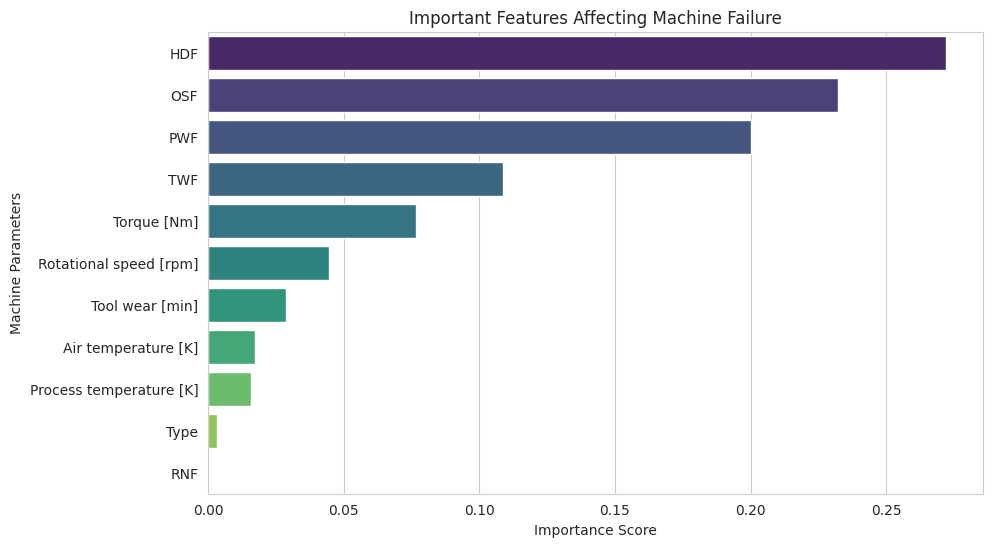

In [11]:
# ===========================================
# Batch 5: Model Evaluation
# ===========================================


# Use best model (Random Forest)

final_model = rf_model

final_prediction = rf_prediction



# Classification Report

print("Classification Report:")
print(
    classification_report(
        y_test,
        final_prediction
    )
)



# Accuracy

print("\nFinal Model Accuracy:")

print(
    accuracy_score(
        y_test,
        final_prediction
    )
)



# ===========================================
# Confusion Matrix
# ===========================================


cm = confusion_matrix(
    y_test,
    final_prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()



# ===========================================
# Feature Importance
# ===========================================


feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": final_model.feature_importances_
    }
)


# Sort values

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("Feature Importance:")

display(feature_importance)



# Plot Feature Importance

plt.figure(figsize=(10,6))


sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)


plt.title(
    "Important Features Affecting Machine Failure"
)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Machine Parameters"
)


plt.show()

In [13]:
# ===========================================
# Fixed Batch 6: Machine Failure Prediction
# ===========================================


def predict_machine_failure(
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear
):

    # Create input dataframe

    input_data = pd.DataFrame(
        {
            "Type": [machine_type],
            "Air temperature [K]": [air_temperature],
            "Process temperature [K]": [process_temperature],
            "Rotational speed [rpm]": [rotational_speed],
            "Torque [Nm]": [torque],
            "Tool wear [min]": [tool_wear]
        }
    )


    # Add missing columns used during training

    for col in X.columns:
        if col not in input_data.columns:
            input_data[col] = 0


    # Arrange columns in same order as training

    input_data = input_data[X.columns]


    # Prediction

    prediction = final_model.predict(input_data)

    probability = final_model.predict_proba(input_data)


    if prediction[0] == 1:

        print("⚠️ Machine Failure Predicted")

    else:

        print("✅ Machine Operating Normally")


    print(
        "\nFailure Probability:",
        round(probability[0][1] * 100, 2),
        "%"
    )



# Test Prediction

predict_machine_failure(
    machine_type=1,
    air_temperature=300,
    process_temperature=310,
    rotational_speed=1500,
    torque=40,
    tool_wear=100
)

✅ Machine Operating Normally

Failure Probability: 0.0 %


In [14]:
# ===========================================
# Batch 7: Retrain Model Without Failure Type Columns
# ===========================================


# Remove failure-related columns from features

drop_columns = [
    "Machine failure",
    "HDF",
    "OSF",
    "PWF",
    "RNF"
]


# Create clean feature dataset

X_clean = df.drop(
    drop_columns,
    axis=1
)


# Target variable

y_clean = df["Machine failure"]



print("Clean Features:")
print(X_clean.columns.tolist())


print("\nFeature Shape:")
print(X_clean.shape)



# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)



# Train Random Forest again

clean_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


clean_rf_model.fit(
    X_train,
    y_train
)



# Prediction

clean_prediction = clean_rf_model.predict(
    X_test
)



# Accuracy

clean_accuracy = accuracy_score(
    y_test,
    clean_prediction
)


print("\nNew Random Forest Accuracy:")
print(round(clean_accuracy*100,2), "%")

Clean Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']

Feature Shape:
(10000, 7)

New Random Forest Accuracy:
98.7 %


In [16]:
# ===========================================
# Batch 7 Fix: Remove All Failure Mode Columns
# ===========================================


# Remove target and failure mode columns

drop_columns = [
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]


# Create final feature dataset

X_clean = df.drop(
    drop_columns,
    axis=1
)


# Target

y_clean = df["Machine failure"]


print("Final Features:")
print(X_clean.columns.tolist())


# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)


# Train final model

clean_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


clean_rf_model.fit(
    X_train,
    y_train
)


# Evaluate

clean_prediction = clean_rf_model.predict(
    X_test
)


accuracy = accuracy_score(
    y_test,
    clean_prediction
)


print("\nFinal Accuracy:")
print(round(accuracy*100,2), "%")

Final Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Final Accuracy:
98.5 %


Final Model Accuracy:
98.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.65      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000



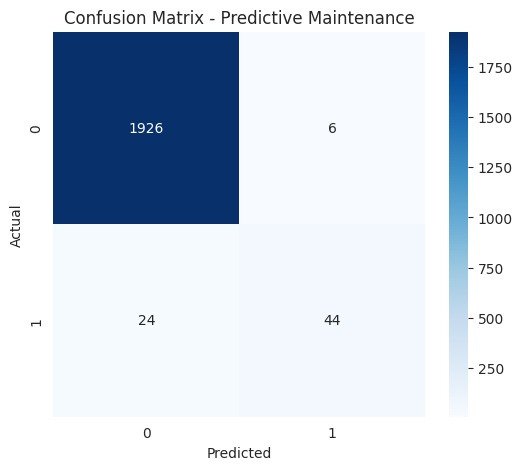


Important Machine Parameters:


,Feature,Importance
4,Torque [Nm],0.325554
3,Rotational speed [rpm],0.226349
5,Tool wear [min],0.164363
1,Air temperature [K],0.130742
2,Process temperature [K],0.128389
0,Type,0.024603


/tmp/ipykernel_1719/2299406311.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


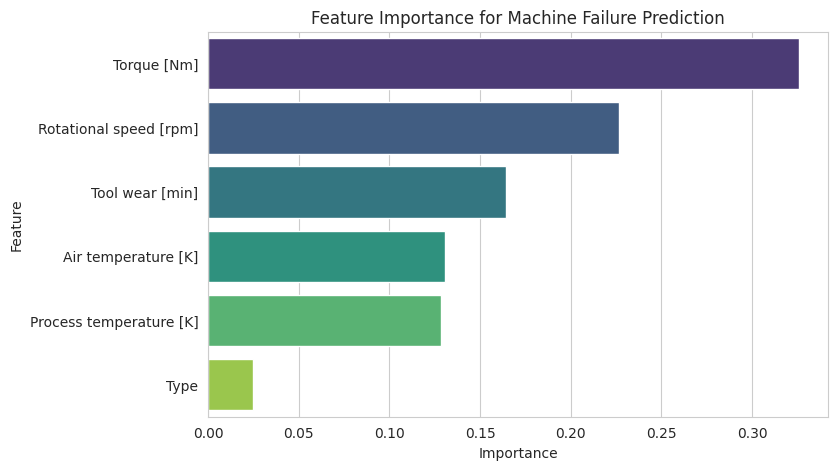

In [17]:
# ===========================================
# Batch 9: Final Model Evaluation
# ===========================================


# Predictions from final clean model

final_prediction = clean_rf_model.predict(
    X_test
)



# Accuracy

final_accuracy = accuracy_score(
    y_test,
    final_prediction
)


print("Final Model Accuracy:")
print(round(final_accuracy * 100, 2), "%")



# Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_prediction
    )
)



# ===========================================
# Confusion Matrix
# ===========================================


cm = confusion_matrix(
    y_test,
    final_prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.title(
    "Confusion Matrix - Predictive Maintenance"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()



# ===========================================
# Feature Importance
# ===========================================


importance = pd.DataFrame(
    {
        "Feature": X_clean.columns,
        "Importance": clean_rf_model.feature_importances_
    }
)


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


print("\nImportant Machine Parameters:")

display(importance)



# Plot Feature Importance

plt.figure(figsize=(8,5))


sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)


plt.title(
    "Feature Importance for Machine Failure Prediction"
)


plt.show()

In [18]:
# ===========================================
# Batch 10: Save Final Model
# ===========================================


# Import joblib

import joblib



# Save trained Random Forest model

joblib.dump(
    clean_rf_model,
    "predictive_maintenance_model.pkl"
)


print("✅ Model saved successfully!")



# Save feature names

joblib.dump(
    list(X_clean.columns),
    "model_features.pkl"
)


print("✅ Feature list saved successfully!")



# ===========================================
# Test Loading Saved Model
# ===========================================


# Load model

loaded_model = joblib.load(
    "predictive_maintenance_model.pkl"
)


# Load features

loaded_features = joblib.load(
    "model_features.pkl"
)



print("\nLoaded Features:")

print(loaded_features)



# Test loaded model prediction

test_prediction = loaded_model.predict(
    X_test.head(5)
)


print("\nTest Predictions:")

print(test_prediction)

✅ Model saved successfully!
✅ Feature list saved successfully!

Loaded Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Test Predictions:
[0 0 0 0 0]
